# 01 — Limpeza e anonimização

## 1. Objetivo

Criar o dataset analítico definitivo a partir do CSV bruto, removendo registros sem paciente, anonimizando identificadores, padronizando textos e convertendo variáveis numéricas. Nenhuma análise inferencial é realizada neste notebook.

As transformações são conservadoras: valores livres ou ambíguos são preservados; somente equivalências inequívocas são normalizadas.

## 2. Importações

In [1]:
from hashlib import sha256
from pathlib import Path
import platform
import re
import sys
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 3. Configuração

In [2]:
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw" / "sociodemografico.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import (
    anonymize_patients,
    clean_numeric_column,
    clean_text_column,
    identify_empty_records,
    remove_empty_records,
)
from src.plots import plot_selection_flow, save_figure
from src.variables import (
    classificar_findrisc,
    classificar_imc,
    create_excesso_peso,
    create_findrisc_alto,
    create_obesidade,
    extract_findrisc_score,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sociodemografico.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "pacientes_clean.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
DIAGNOSIS_MAPPING_PATH = TABLES_DIR / "diagnosis_mapping.csv"
DIAGNOSIS_DISTRIBUTION_PATH = TABLES_DIR / "diagnosis_distribution.csv"
FLOW_FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures" / "data_cleaning_flow.png"
RAW_HASH_BEFORE = sha256(RAW_PATH.read_bytes()).hexdigest()

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")

Python: 3.14.6
pandas: 3.0.5


## 4. Carregamento

O arquivo bruto é somente lido. Nenhuma amostra de linhas é exibida para evitar exposição de identificadores.

In [3]:
df_raw = pd.read_csv(RAW_PATH)
n_raw = len(df_raw)
empty_record_mask = identify_empty_records(df_raw, patient_column="nome")
n_empty = int(empty_record_mask.sum())
n_valid = n_raw - n_empty

print(f"Linhas no arquivo bruto: {n_raw}")
print(f"Registros sem paciente: {n_empty}")
print(f"Pacientes válidos: {n_valid}")

Linhas no arquivo bruto: 100
Registros sem paciente: 25
Pacientes válidos: 75


## 5. Validações pré-limpeza

A regra de paciente válido é a presença de conteúdo nominal após remoção de espaços. As linhas excluídas não possuem dados clínicos preenchidos além de campos estruturais/padrão.

In [4]:
clinical_columns = [column for column in df_raw.columns if column not in {
    "Cod", "nome", "usa ou usou corticoide recente?"
}]
excluded_with_clinical_data = (
    df_raw.loc[empty_record_mask, clinical_columns]
    .apply(lambda series: clean_text_column(series).notna())
    .any(axis=1)
)

assert not excluded_with_clinical_data.any(), (
    "Há linha sem paciente contendo dado clínico; interromper para revisão manual."
)
assert not df_raw.loc[~empty_record_mask, "nome"].astype("string").str.strip().duplicated().any()
assert not df_raw.loc[~empty_record_mask, "Cod"].duplicated().any()
print("Regra de elegibilidade validada sem exibir dados individuais.")

Regra de elegibilidade validada sem exibir dados individuais.


## 6. Limpeza e transformação

### 6.1 Remoção dos registros sem paciente e anonimização

O código original também é removido para impedir ligação direta com o arquivo fonte.

In [5]:
df_valid = remove_empty_records(df_raw, patient_column="nome")
df = anonymize_patients(df_valid, name_column="nome")
df = df.drop(columns=["Cod"])

assert len(df) == n_valid
assert df["patient_id"].is_unique
assert df["patient_id"].notna().all()
assert df["patient_id"].str.fullmatch(r"P\d{3}").all()
assert "nome" not in df.columns and "Cod" not in df.columns
print(f"{len(df)} pacientes anonimizados; identificadores originais removidos.")

75 pacientes anonimizados; identificadores originais removidos.


### 6.2 Padronização dos nomes das variáveis

In [6]:
COLUMN_RENAME = {
    "estado civil": "estado_civil",
    "escolaridade": "escolaridade",
    "ocupação ": "ocupacao",
    "renda mensal familiar": "renda_mensal_familiar",
    "diagnóstico principal": "diagnostico_original",
    "tempo de diagnóstico": "tempo_diagnostico",
    "usa ou usou corticoide recente?": "uso_corticoide",
    "faz uso de medicamento imunobiologico? ": "uso_imunobiologico",
    "tempo de medicamento": "tempo_medicamento",
    "circunferência cervical": "circunferencia_cervical",
    "CT": "colesterol_total",
    "LDL": "ldl",
    "HDL": "hdl",
    "VRDL": "vrdl",
    "TG": "triglicerideos",
    "Glicemia": "glicemia",
    "hbA1c": "hba1c",
    "PA": "pressao_arterial",
    "Altura": "altura",
    "Peso": "peso",
    "IMC": "imc",
    "CA": "circunferencia_abdominal",
    "comorbidade associada/medicamento": "comorbidade_medicamento",
    "tabagismo": "tabagismo",
    "etilismo": "etilismo",
    "ativ física?": "atividade_fisica",
    "resultado do findrisk": "findrisc_original",
    "resultado BASDAI": "basdai",
    "resultado SLICC": "slicc",
    "resultado DAS-28": "das28",
}

unmapped_columns = set(df.columns) - {"patient_id", *COLUMN_RENAME}
assert not unmapped_columns, f"Colunas brutas sem mapeamento: {sorted(unmapped_columns)}"
df = df.rename(columns=COLUMN_RENAME)
assert all(column == column.strip() and column.isascii() for column in df.columns)
print(f"{len(COLUMN_RENAME)} nomes de variáveis padronizados para snake_case.")

30 nomes de variáveis padronizados para snake_case.


### 6.3 Limpeza textual e categorias inequívocas

`diagnostico_original` e `findrisc_original` preservam exatamente o conteúdo fonte. O diagnóstico padronizado é criado separadamente. Campos livres mistos não são forçados para categorias binárias. A distribuição diagnóstica é exclusivamente descritiva: a análise principal mantém todos os pacientes em uma única coorte, sem testes comparativos entre doenças.

In [7]:
def category_key(value):
    if pd.isna(value):
        return pd.NA
    normalized = unicodedata.normalize("NFKD", str(value))
    normalized = "".join(char for char in normalized if not unicodedata.combining(char))
    normalized = re.sub(r"\s*,\s*", ", ", normalized)
    return re.sub(r"\s+", " ", normalized.strip().casefold())

def standardize_known_categories(series, mapping):
    cleaned = clean_text_column(series)
    keys = cleaned.map(category_key)
    mapped = keys.map(mapping).astype("string")
    return mapped.fillna(cleaned)

text_columns = [
    "estado_civil", "escolaridade", "ocupacao", "renda_mensal_familiar",
    "tempo_diagnostico", "uso_imunobiologico", "tempo_medicamento",
    "pressao_arterial", "comorbidade_medicamento", "tabagismo",
    "etilismo", "atividade_fisica",
]
for column in text_columns:
    df[column] = clean_text_column(df[column])

category_maps = {
    "estado_civil": {
        "solteiro": "Solteiro", "casado": "Casado",
        "viuvo": "Viúvo", "divorciado": "Divorciado",
    },
    "escolaridade": {
        "ensino fundamental incompleto": "Ensino fundamental incompleto",
        "ensino fundamental completo": "Ensino fundamental completo",
        "ensino medio incompleto": "Ensino médio incompleto",
        "ensino medio completo": "Ensino médio completo",
        "superior incompleto": "Superior incompleto",
        "superior completo": "Superior completo",
        "sem instrucao": "Sem instrução",
    },
    "renda_mensal_familiar": {
        "ate 1 salario minimo": "Até 1 salário mínimo",
        "1 a 2 salarios minimos": "1 a 2 salários mínimos",
        "2 a 3 salarios minimos": "2 a 3 salários mínimos",
        "acima de 3 salarios minimos": "Acima de 3 salários mínimos",
    },
}
for column, mapping in category_maps.items():
    df[column] = standardize_known_categories(df[column], mapping)

simple_yes_no = {"sim": "Sim", "nao": "Não"}
for column in ["uso_imunobiologico", "tabagismo", "etilismo", "atividade_fisica"]:
    df[column] = standardize_known_categories(df[column], simple_yes_no)

df["uso_corticoide"] = df["uso_corticoide"].astype("boolean")

In [8]:
DIAGNOSIS_MAPPING = {
    "lupus eritematoso": "Lúpus eritematoso",
    "artrite reumatoide": "Artrite reumatoide",
    "espondiloartrite": "Espondiloartrite",
    "doenca de bc": "Doença de BC",
    "osteoporose, arterite temporal, artrose": "Osteoporose, Arterite temporal, Artrose",
    "artrite reumatoide, artrose, fibromialgia, lupus eritematoso": "Artrite reumatoide, Artrose, Fibromialgia, Lúpus eritematoso",
    "lupus eritematoso, fibromialgia": "Lúpus eritematoso, Fibromialgia",
    "artrite reumatoide, artrose": "Artrite reumatoide, Artrose",
    "artrose": "Artrose",
    "lupus eritematoso e fibromialgia": "Lúpus eritematoso, Fibromialgia",
    "fibromialgia, artrose, osteoporose": "Fibromialgia, Artrose, Osteoporose",
    "osteoporose": "Osteoporose",
    "saf (sindrome antifosfolipidica)": "Síndrome antifosfolipídica (SAF)",
    "em descoberta": "Em descoberta",
}

diagnosis_clean = clean_text_column(df["diagnostico_original"])
diagnosis_keys = diagnosis_clean.map(category_key)
df["diagnostico_padronizado"] = (
    diagnosis_keys.map(DIAGNOSIS_MAPPING).astype("string").fillna(diagnosis_clean)
)
n_unmapped_diagnoses = int((diagnosis_keys.notna() & ~diagnosis_keys.isin(DIAGNOSIS_MAPPING)).sum())

diagnosis_mapping_reference = pd.DataFrame({
    "forma_normalizada": list(DIAGNOSIS_MAPPING),
    "diagnostico_padronizado": list(DIAGNOSIS_MAPPING.values()),
})
display(diagnosis_mapping_reference)
print(f"Diagnósticos sem regra explícita, preservados após limpeza textual: {n_unmapped_diagnoses}")

diagnosis_mapping_table = (
    pd.DataFrame({
        "diagnostico_original": df["diagnostico_original"],
        "diagnostico_normalizado": diagnosis_keys,
        "diagnostico_padronizado": df["diagnostico_padronizado"],
    })
    .groupby(
        ["diagnostico_original", "diagnostico_normalizado", "diagnostico_padronizado"],
        dropna=False, sort=False,
    )
    .size()
    .rename("n_registros")
    .reset_index()
    .sort_values(["n_registros", "diagnostico_original"], ascending=[False, True])
    .reset_index(drop=True)
)
n_valid_diagnosis = int(df["diagnostico_padronizado"].notna().sum())
diagnosis_distribution = (
    df["diagnostico_padronizado"]
    .value_counts(dropna=True)
    .rename_axis("diagnostico")
    .reset_index(name="n")
)
diagnosis_distribution["percentual"] = (
    100 * diagnosis_distribution["n"] / n_valid_diagnosis
).round(2)
original_multiple_diagnoses = df["diagnostico_original"].astype("string").str.contains(
    r",|\se\s", case=False, regex=True, na=False
)
standardized_multiple_diagnoses = (
    df["diagnostico_padronizado"].astype("string").str.contains(",", regex=False, na=False)
)
assert int(original_multiple_diagnoses.sum()) == int(standardized_multiple_diagnoses.sum())
assert diagnosis_distribution["n"].sum() == n_valid_diagnosis

print("Distribuição diagnóstica descritiva")
print(f"Diagnósticos válidos: {n_valid_diagnosis}")
print(f"Categorias padronizadas: {df['diagnostico_padronizado'].nunique(dropna=True)}")
print(
    "Registros com diagnósticos múltiplos preservados: "
    f"{int(standardized_multiple_diagnoses.sum())}"
)
print(f"Coorte analítica única: {len(df)} pacientes")
print("Sem testes comparativos entre diagnósticos.")
display(diagnosis_distribution)

,forma_normalizada,diagnostico_padronizado
0,lupus eritematoso,Lúpus eritematoso
1,artrite reumatoide,Artrite reumatoide
2,espondiloartrite,Espondiloartrite
3,doenca de bc,Doença de BC
4,"osteoporose, arterite temporal, artrose","Osteoporose, Arterite temporal, Artrose"
5,"artrite reumatoide, artrose, fibromialgia, lup...","Artrite reumatoide, Artrose, Fibromialgia, Lúp..."
6,"lupus eritematoso, fibromialgia","Lúpus eritematoso, Fibromialgia"
7,"artrite reumatoide, artrose","Artrite reumatoide, Artrose"
8,artrose,Artrose
9,lupus eritematoso e fibromialgia,"Lúpus eritematoso, Fibromialgia"


Diagnósticos sem regra explícita, preservados após limpeza textual: 0
Distribuição diagnóstica descritiva
Diagnósticos válidos: 75
Categorias padronizadas: 13
Registros com diagnósticos múltiplos preservados: 6
Coorte analítica única: 75 pacientes
Sem testes comparativos entre diagnósticos.


,diagnostico,n,percentual
0,Lúpus eritematoso,26,34.67
1,Artrite reumatoide,23,30.67
2,Espondiloartrite,14,18.67
3,"Lúpus eritematoso, Fibromialgia",2,2.67
4,Doença de BC,2,2.67
5,"Osteoporose, Arterite temporal, Artrose",1,1.33
6,"Artrite reumatoide, Artrose, Fibromialgia, Lúp...",1,1.33
7,"Artrite reumatoide, Artrose",1,1.33
8,Artrose,1,1.33
9,"Fibromialgia, Artrose, Osteoporose",1,1.33


### 6.4 Conversões numéricas e variáveis derivadas

Falhas de conversão permanecem ausentes. FINDRISC é extraído do início do campo original e sua categoria é recalculada exclusivamente pela pontuação.

In [9]:
numeric_columns = [
    "circunferencia_cervical", "colesterol_total", "ldl", "hdl",
    "vrdl", "triglicerideos", "glicemia", "altura", "peso",
    "imc", "circunferencia_abdominal", "basdai", "slicc", "das28",
]
for column in numeric_columns:
    df[column] = clean_numeric_column(df[column])

hba1c_without_unit = clean_text_column(df["hba1c"]).str.replace("%", "", regex=False)
df["hba1c"] = clean_numeric_column(hba1c_without_unit)

df["findrisc_score"] = extract_findrisc_score(df["findrisc_original"])

invalid_imc = df["imc"].notna() & ~df["imc"].between(10, 80)
invalid_findrisc = df["findrisc_score"].notna() & ~df["findrisc_score"].between(0, 26)
assert not invalid_imc.any(), "IMC fora da faixa de auditoria; interromper para revisão."
assert not invalid_findrisc.any(), "FINDRISC fora da faixa válida do instrumento."

df["imc_categoria"] = df["imc"].map(classificar_imc).astype("string")
df["excesso_peso"] = create_excesso_peso(df["imc"])
df["obesidade"] = create_obesidade(df["imc"])
df["findrisc_categoria"] = (
    df["findrisc_score"].map(classificar_findrisc).astype("string")
)
df["findrisc_alto"] = create_findrisc_alto(df["findrisc_score"])

source_imc = clean_text_column(df_valid["IMC"]).reset_index(drop=True)
converted_imc = df["imc"].reset_index(drop=True)
n_imc_conversion_failures = int((source_imc.notna() & converted_imc.isna()).sum())
imc_valid = converted_imc.dropna()
imc_q1, imc_q3 = imc_valid.quantile([0.25, 0.75])
imc_iqr = imc_q3 - imc_q1
imc_iqr_lower = imc_q1 - 1.5 * imc_iqr
imc_iqr_upper = imc_q3 + 1.5 * imc_iqr
n_imc_iqr_extremes = int((~imc_valid.between(imc_iqr_lower, imc_iqr_upper)).sum())

IMC_CATEGORY_ORDER = [
    "Baixo peso", "Peso normal", "Sobrepeso", "Obesidade grau I",
    "Obesidade grau II", "Obesidade grau III",
]
imc_category_counts = (
    df["imc_categoria"].value_counts().reindex(IMC_CATEGORY_ORDER, fill_value=0)
)
imc_category_summary = pd.DataFrame({
    "categoria": IMC_CATEGORY_ORDER,
    "n": imc_category_counts.to_numpy(),
    "percentual_valido": (100 * imc_category_counts / len(imc_valid)).round(2).to_numpy(),
})

print("Resumo de validação do IMC")
print(f"N com IMC válido: {len(imc_valid)}")
print(f"N sem IMC: {converted_imc.isna().sum()}")
print(f"Mínimo: {imc_valid.min():.2f}")
print(f"Máximo: {imc_valid.max():.2f}")
print(f"Falhas de conversão: {n_imc_conversion_failures}")
print(f"Valores impossíveis: {int(invalid_imc.sum())}")
print(f"Extremos pelo critério de IQR: {n_imc_iqr_extremes}")
display(imc_category_summary)
assert n_imc_conversion_failures == 0, "Há IMC preenchido que não foi convertido."

findrisc_valid = df["findrisc_score"].dropna()
n_findrisc_conversion_failures = int(
    (df["findrisc_original"].notna() & df["findrisc_score"].isna()).sum()
)
FINDRISC_CATEGORY_ORDER = [
    "Baixo risco", "Leve/moderado", "Moderado", "Alto", "Muito alto",
]
findrisc_category_counts = (
    df["findrisc_categoria"].value_counts().reindex(FINDRISC_CATEGORY_ORDER, fill_value=0)
)
findrisc_category_summary = pd.DataFrame({
    "categoria": FINDRISC_CATEGORY_ORDER,
    "n": findrisc_category_counts.to_numpy(),
    "percentual_valido": (
        100 * findrisc_category_counts / len(findrisc_valid)
    ).round(2).to_numpy(),
})

findrisc_original_labels = (
    df["findrisc_original"].astype("string")
    .str.extract(r"\((.*?)\)", expand=False)
    .map(category_key)
)
STRICT_FINDRISC_LABEL_MAPPING = {
    "baixo risco": "Baixo risco",
    "leve/moderado": "Leve/moderado",
    "leve moderado": "Leve/moderado",
    "moderado": "Moderado",
    "risco moderado": "Moderado",
    "alto risco": "Alto",
    "risco alto": "Alto",
    "muito alto risco": "Muito alto",
    "risco muito alto": "Muito alto",
}
CLINICAL_FINDRISC_LABEL_MAPPING = {
    **STRICT_FINDRISC_LABEL_MAPPING,
    "muito baixo risco": "Baixo risco",
}
original_category_strict = findrisc_original_labels.map(STRICT_FINDRISC_LABEL_MAPPING)
original_category_clinical = findrisc_original_labels.map(CLINICAL_FINDRISC_LABEL_MAPPING)
labeled_findrisc = findrisc_original_labels.notna()
nonstandard_findrisc_label = labeled_findrisc & original_category_strict.isna()
strict_findrisc_divergence = labeled_findrisc & (
    original_category_strict.isna()
    | ~original_category_strict.eq(df["findrisc_categoria"]).fillna(False)
)
clinical_findrisc_divergence = labeled_findrisc & (
    ~original_category_clinical.eq(df["findrisc_categoria"]).fillna(False)
)
findrisc_label_comparison = pd.DataFrame({
    "categoria_original_normalizada": original_category_strict.fillna(
        "Rótulo não padronizado"
    ),
    "categoria_recalculada": df["findrisc_categoria"],
}).loc[labeled_findrisc].value_counts().rename("n").reset_index()

print("Resumo de validação do FINDRISC")
print(f"N com FINDRISC válido: {len(findrisc_valid)}")
print(f"N sem FINDRISC: {df['findrisc_score'].isna().sum()}")
print(f"Mínimo: {int(findrisc_valid.min())}")
print(f"Máximo: {int(findrisc_valid.max())}")
print(f"Falhas de conversão: {n_findrisc_conversion_failures}")
print(f"Valores fora da faixa 0–26: {int(invalid_findrisc.sum())}")
print(f"FINDRISC ≥15: {int(df['findrisc_alto'].sum())}")
print(f"Rótulos originais presentes: {int(labeled_findrisc.sum())}")
print(f"Divergências estritas: {int(strict_findrisc_divergence.sum())}")
print(f"Divergências clínicas: {int(clinical_findrisc_divergence.sum())}")
print(f"Rótulos não padronizados: {int(nonstandard_findrisc_label.sum())}")
display(findrisc_category_summary)
display(findrisc_label_comparison)
assert n_findrisc_conversion_failures == 0, (
    "Há FINDRISC preenchido cuja pontuação não foi extraída."
)

Resumo de validação do IMC
N com IMC válido: 73
N sem IMC: 2
Mínimo: 17.50
Máximo: 41.10
Falhas de conversão: 0
Valores impossíveis: 0
Extremos pelo critério de IQR: 0


,categoria,n,percentual_valido
0,Baixo peso,3,4.11
1,Peso normal,18,24.66
2,Sobrepeso,26,35.62
3,Obesidade grau I,15,20.55
4,Obesidade grau II,9,12.33
5,Obesidade grau III,2,2.74


Resumo de validação do FINDRISC
N com FINDRISC válido: 74
N sem FINDRISC: 1
Mínimo: 2
Máximo: 24
Falhas de conversão: 0
Valores fora da faixa 0–26: 0
FINDRISC ≥15: 35
Rótulos originais presentes: 9
Divergências estritas: 3
Divergências clínicas: 2
Rótulos não padronizados: 1


,categoria,n,percentual_valido
0,Baixo risco,10,13.51
1,Leve/moderado,18,24.32
2,Moderado,11,14.86
3,Alto,20,27.03
4,Muito alto,15,20.27


,categoria_original_normalizada,categoria_recalculada,n
0,Muito alto,Muito alto,3
1,Alto,Alto,2
2,Rótulo não padronizado,Baixo risco,1
3,Moderado,Alto,1
4,Moderado,Moderado,1
5,Baixo risco,Leve/moderado,1


In [10]:
ANALYTIC_COLUMNS = [
    "patient_id", "estado_civil", "escolaridade", "ocupacao",
    "renda_mensal_familiar", "diagnostico_original", "diagnostico_padronizado",
    "tempo_diagnostico", "uso_corticoide", "uso_imunobiologico",
    "tempo_medicamento", "circunferencia_cervical", "colesterol_total",
    "ldl", "hdl", "vrdl", "triglicerideos", "glicemia", "hba1c",
    "pressao_arterial", "altura", "peso", "imc", "imc_categoria",
    "excesso_peso", "obesidade", "circunferencia_abdominal",
    "comorbidade_medicamento", "tabagismo", "etilismo", "atividade_fisica",
    "findrisc_original", "findrisc_score", "findrisc_categoria",
    "findrisc_alto", "basdai", "slicc", "das28",
]
assert set(df.columns) == set(ANALYTIC_COLUMNS)
df = df[ANALYTIC_COLUMNS].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                75 non-null     string 
 1   estado_civil              75 non-null     string 
 2   escolaridade              75 non-null     string 
 3   ocupacao                  75 non-null     string 
 4   renda_mensal_familiar     75 non-null     string 
 5   diagnostico_original      75 non-null     str    
 6   diagnostico_padronizado   75 non-null     string 
 7   tempo_diagnostico         73 non-null     string 
 8   uso_corticoide            75 non-null     boolean
 9   uso_imunobiologico        63 non-null     string 
 10  tempo_medicamento         35 non-null     string 
 11  circunferencia_cervical   75 non-null     Float64
 12  colesterol_total          24 non-null     Float64
 13  ldl                       24 non-null     Float64
 14  hdl                    

## 7. Validação e visualização do fluxo

As validações abaixo confirmam privacidade, unicidade, preservação de missing e imutabilidade do bruto antes da exportação.

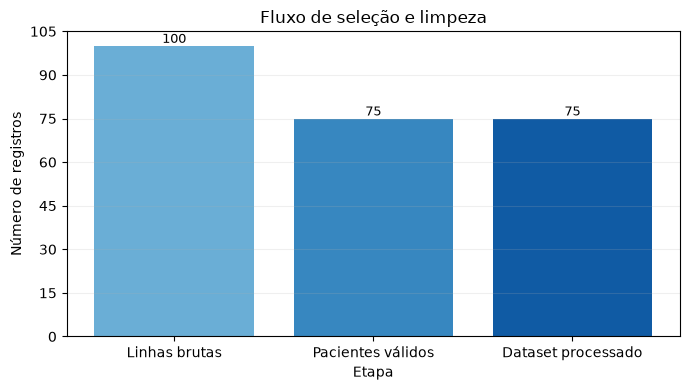

In [11]:
assert df["patient_id"].is_unique
assert df["patient_id"].notna().all()
assert not any(column.casefold() in {"nome", "cod"} for column in df.columns)
assert df["imc"].isna().equals(df["imc_categoria"].isna())
assert df["imc"].isna().equals(df["excesso_peso"].isna())
assert df["imc"].isna().equals(df["obesidade"].isna())
assert df["findrisc_score"].isna().equals(df["findrisc_categoria"].isna())
assert df["findrisc_score"].isna().equals(df["findrisc_alto"].isna())
assert sha256(RAW_PATH.read_bytes()).hexdigest() == RAW_HASH_BEFORE

protected_names = clean_text_column(df_valid["nome"]).dropna().str.casefold()
serialized_analytic_data = df.to_csv(index=False).casefold()
assert not protected_names.map(lambda value: value in serialized_analytic_data).any()

flow_counts = pd.Series(
    {"Linhas brutas": n_raw, "Pacientes válidos": n_valid, "Dataset processado": len(df)}
)
figure, _ = plot_selection_flow(flow_counts)
save_figure(figure, FLOW_FIGURE_PATH)
plt.show()

## 8. Conclusões deste notebook

In [12]:
print(f"Amostra final: {len(df)} pacientes.")
print(f"Registros sem paciente removidos: {n_empty}.")
print(f"IMC: {df['imc'].notna().sum()} válidos e {df['imc'].isna().sum()} ausentes.")
print(
    f"FINDRISC: {df['findrisc_score'].notna().sum()} válidos e "
    f"{df['findrisc_score'].isna().sum()} ausentes."
)
print("Nome e código original removidos; patient_id é único.")
print("Diagnóstico e FINDRISC originais preservados em colunas separadas.")
print("Campos ambíguos foram preservados sem inferência clínica automática.")

Amostra final: 75 pacientes.
Registros sem paciente removidos: 25.
IMC: 73 válidos e 2 ausentes.
FINDRISC: 74 válidos e 1 ausentes.
Nome e código original removidos; patient_id é único.
Diagnóstico e FINDRISC originais preservados em colunas separadas.
Campos ambíguos foram preservados sem inferência clínica automática.


## 9. Output gerado

In [13]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False, encoding="utf-8")
diagnosis_mapping_table.to_csv(DIAGNOSIS_MAPPING_PATH, index=False, encoding="utf-8")
diagnosis_distribution.to_csv(
    DIAGNOSIS_DISTRIBUTION_PATH, index=False, encoding="utf-8"
)

reloaded = pd.read_csv(PROCESSED_PATH)
assert len(reloaded) == len(df)
assert reloaded["patient_id"].is_unique
assert "nome" not in reloaded.columns and "Cod" not in reloaded.columns
assert reloaded["imc"].isna().sum() == df["imc"].isna().sum()
assert reloaded["findrisc_score"].isna().sum() == df["findrisc_score"].isna().sum()
assert sha256(RAW_PATH.read_bytes()).hexdigest() == RAW_HASH_BEFORE
for output_path in [PROCESSED_PATH, DIAGNOSIS_MAPPING_PATH, DIAGNOSIS_DISTRIBUTION_PATH]:
    assert output_path.exists() and output_path.stat().st_size > 0
    print(output_path.relative_to(PROJECT_ROOT))

data/processed/pacientes_clean.csv
outputs/tables/diagnosis_mapping.csv
outputs/tables/diagnosis_distribution.csv
